In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.14.1+cu126
True
NVIDIA GeForce RTX 3060 Ti


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_data = datasets.MNIST(root = "data", train = True, download = True, transform = transform)
test_data = datasets.MNIST(root = "data", train = False, download = True, transform = transform)

print(len(train_data), len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 810kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.06MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.0MB/s]

60000 10000


In [6]:
print(train_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [7]:
print(train_data.data.shape)
print(train_data.data.dtype)
print(train_data.targets[:10])

torch.Size([60000, 28, 28])
torch.uint8
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])


Data (Training):
We have 60000 images. It's 28 x 28 grid, a total of 784 pixels.
1 pixel is a number ranging from 0 to 255. 

In [8]:
image, label = train_data[0]
print(image.shape)
print(label)
print(image.min(), image.max())

torch.Size([1, 28, 28])
5
tensor(0.) tensor(1.)


In [9]:
torch.set_printoptions(linewidth=200)
print(train_data.data[0])

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170, 253, 253, 253, 253, 253, 2

In [10]:
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 64)

In [11]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels[:10])

torch.Size([64, 1, 28, 28])
tensor([9, 4, 8, 0, 7, 7, 8, 8, 5, 3])


torch.Size([64, 1, 28, 28])
64 batches, 1 brightness (black and white), Height, Width

RGB would be 64, 3, 28, 28

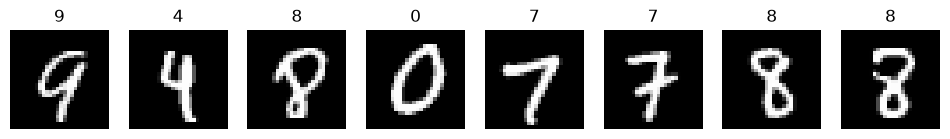

In [25]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 8, figsize = (12, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap = "gray")
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.show()